Train Dataset Shape: (891, 12)
Test Dataset Shape: (418, 11)
Gender Submission Shape: (418, 2)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S 

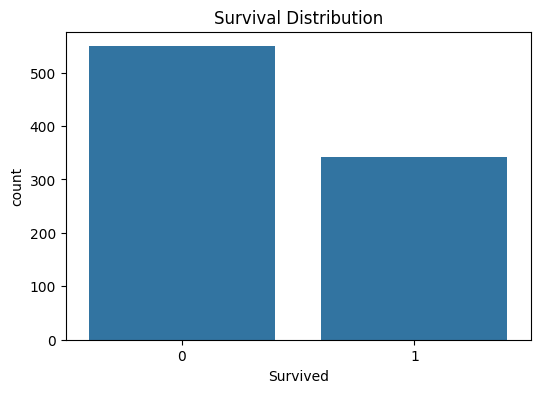

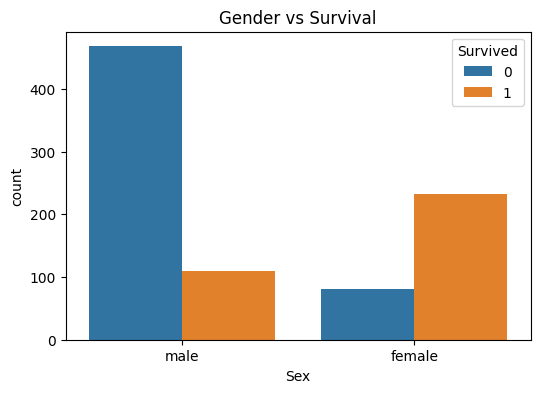

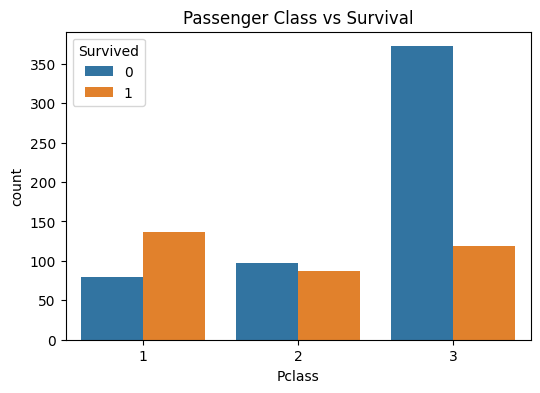

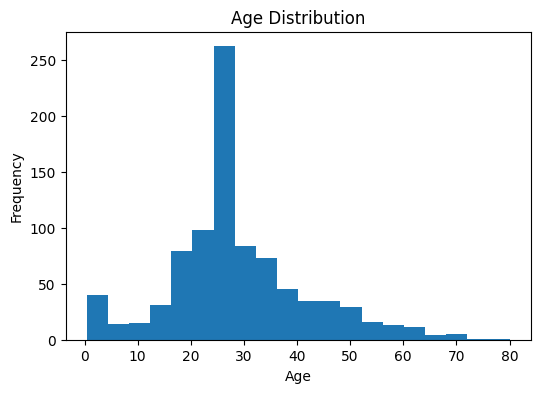

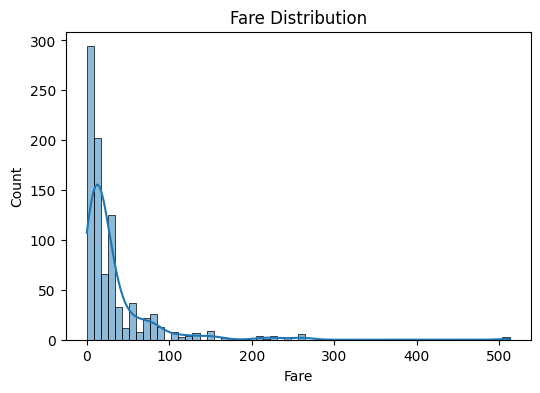

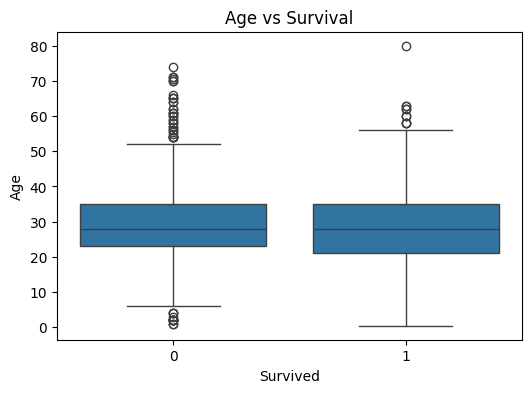

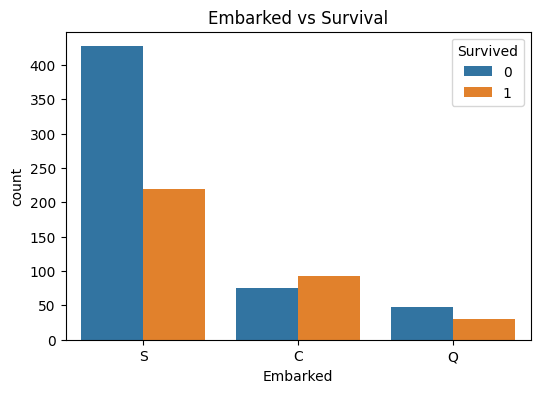

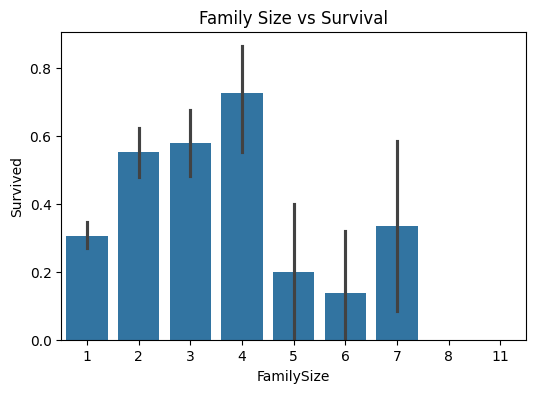

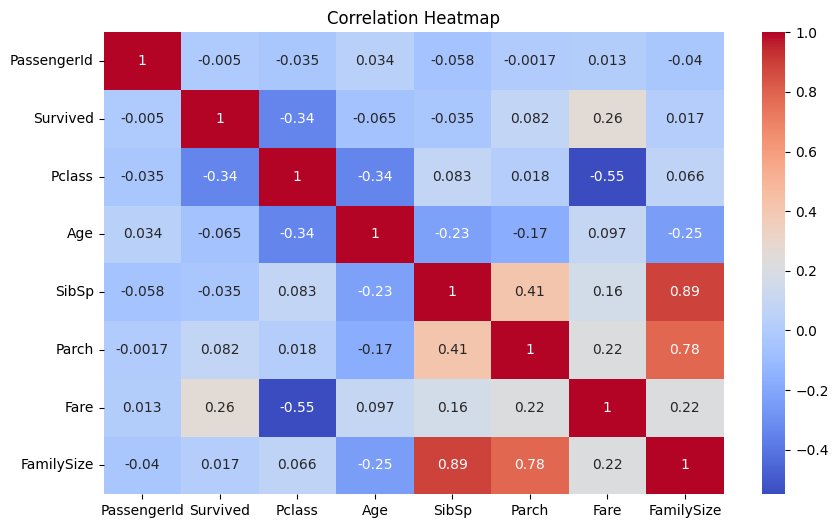


===== KEY FINDINGS =====
1. Female passengers had a higher survival rate than males.
2. First-class passengers survived more frequently.
3. Higher fare passengers had better chances of survival.
4. Most passengers were between 20–40 years old.
5. Passenger class and gender strongly influenced survival.
6. Family size showed some impact on survival.
7. Embarkation point also affected survival trends.


In [1]:
# ==========================
# TASK 2: Data Cleaning & EDA
# Titanic Dataset
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# Load Datasets
# --------------------------

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("gender_submission.csv")

print("Train Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)
print("Gender Submission Shape:", submission.shape)

# Use train dataset for cleaning and EDA
df = train.copy()

# --------------------------
# Basic Information
# --------------------------

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# --------------------------
# Data Cleaning
# --------------------------

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# --------------------------
# Exploratory Data Analysis
# --------------------------

# Survival Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

# Gender vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

# Passenger Class vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

# Survival by Age
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

# Survival by Embarked
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Embarked vs Survival")
plt.show()

# Survival by Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(6,4))
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()

# --------------------------
# Correlation Heatmap
# --------------------------

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# Findings
# --------------------------

print("\n===== KEY FINDINGS =====")
print("1. Female passengers had a higher survival rate than males.")
print("2. First-class passengers survived more frequently.")
print("3. Higher fare passengers had better chances of survival.")
print("4. Most passengers were between 20–40 years old.")
print("5. Passenger class and gender strongly influenced survival.")
print("6. Family size showed some impact on survival.")
print("7. Embarkation point also affected survival trends.")